# 📈 Day 133 — Time Series Analysis: ARIMA & Stationarity
**Month 7 | Week 3 | RetailPulse India | seed=121 | 500 rows**

---

| Field | Value |
|---|---|
| **Max Score** | 80 pts + 10★ bonus |
| **Tools** | statsmodels, pandas, numpy, matplotlib, seaborn |
| **Topic** | Time Series, ADF Test, ARIMA(p,d,q), Forecasting |
| **GitHub** | Month7-AdvancedML-Portfolio |

---

## Why Time Series Is a Freelance Priority

| Client Type | Problem | Time Series Answer |
|---|---|---|
| E-commerce | "How much stock should I order next month?" | ARIMA revenue forecast → reorder trigger |
| Retail chain | "When do our slow weeks hit?" | Seasonality decomposition → staffing plan |
| Finance | "Project my monthly expenses" | ARIMA(p,d,q) → rolling forecast |
| Startup | "When will we hit ₹10L monthly revenue?" | Trend extrapolation → investor deck |

> **Key insight:** Traditional ML (XGBoost, LightGBM) ignores time ordering.
> Time series models are built around it — they use **autocorrelation** (today predicts tomorrow).

---

## ARIMA Fundamentals

### The Three Parameters

| Parameter | Name | Meaning | How to choose |
|---|---|---|---|
| **p** | Autoregressive order | How many past values to use | ACF/PACF plot, starts at 1 |
| **d** | Differencing order | How many times to difference for stationarity | ADF test — d=0 if stationary, d=1 usually fixes it |
| **q** | Moving average order | How many past errors to use | ACF/PACF plot, starts at 1 |

### The ARIMA(1,1,1) Equation

```
Δy_t = c + φ₁·Δy_{t-1} + θ₁·ε_{t-1} + ε_t
```

Where:
- **Δy_t** = first difference (y_t - y_{t-1})
- **φ₁** = AR coefficient (weight of previous differenced value)
- **θ₁** = MA coefficient (weight of previous error)
- **ε_t** = white noise

### Stationarity — Why It Matters

A stationary series has **constant mean, variance, and autocorrelation** over time.
ARIMA requires stationarity in the differenced series.

| Property | Non-Stationary (bad) | Stationary (good) |
|---|---|---|
| Mean | Changes over time (trend) | Flat/constant |
| Variance | Grows/shrinks | Consistent |
| ACF | Decays slowly | Drops quickly |
| ADF p-value | > 0.05 (fail to reject H₀) | < 0.05 (reject H₀) |

### ADF Test Interpretation

```
H₀: Series has a unit root (non-stationary)  ← the null hypothesis
H₁: Series is stationary

p < 0.05  → Reject H₀ → Series IS stationary ✅
p ≥ 0.05  → Fail to reject H₀ → Series is NOT stationary ❌ → apply differencing
```

---

## Section 1 — Raw Data (⛔ Never Modify This Section)


In [2]:
# ═══════════════════════════════════════════════════════════════════
# SECTION 1: RAW DATA — DO NOT MODIFY ANYTHING IN THIS CELL
# ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(121)
n = 500

categories = ['Electronics', 'Clothing', 'Groceries', 'Home & Kitchen', 'Sports']
cities     = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Pune']
payments   = ['UPI', 'Credit Card', 'Debit Card', 'Cash', 'Net Banking']

RAW = pd.DataFrame({
    'order_id'      : range(1001, 1001 + n),
    'order_date'    : pd.date_range('2023-01-01', periods=n, freq='D'),
    'customer_id'   : np.random.randint(1, 201, n),
    'category'      : np.random.choice(categories, n),
    'city'          : np.random.choice(cities, n),
    'quantity'      : np.random.randint(1, 11, n),
    'unit_price'    : np.round(np.random.uniform(50, 5000, n), 2),
    'discount_pct'  : np.random.choice([0, 5, 10, 15, 20], n),
    'payment_method': np.random.choice(payments, n),
    'returned'      : np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'churned'       : np.random.choice([0, 1], n, p=[0.7, 0.3])
})
RAW['revenue'] = np.round(
    RAW['quantity'] * RAW['unit_price'] * (1 - RAW['discount_pct'] / 100), 2
)

print(f"Raw data shape: {RAW.shape}")
print(f"Date range: {RAW['order_date'].min().date()} → {RAW['order_date'].max().date()}")
print(RAW[['order_date','category','revenue']].head(8))


Raw data shape: (500, 12)
Date range: 2023-01-01 → 2024-05-14
  order_date        category   revenue
0 2023-01-01          Sports   1404.38
1 2023-01-02        Clothing   1078.04
2 2023-01-03  Home & Kitchen  19646.29
3 2023-01-04  Home & Kitchen   9764.06
4 2023-01-05          Sports  15467.45
5 2023-01-06     Electronics  35095.46
6 2023-01-07          Sports  25877.15
7 2023-01-08          Sports   4565.59


---
## Section 2 — Concept Notes

### Time Series Terminology

| Term | Definition | RetailPulse Example |
|---|---|---|
| **Trend** | Long-term directional movement | Revenue growing Q3→Q4 |
| **Seasonality** | Repeating cycle at fixed intervals | Weekly revenue dip on Tuesdays |
| **Noise / Residual** | Random fluctuation | One-off bulk order spike |
| **Autocorrelation** | Correlation of series with its own past values | High Jan revenue → predicts Feb revenue |
| **Stationarity** | Statistical properties constant over time | Required before fitting ARIMA |

### ACF vs PACF

| Plot | What It Shows | Use For |
|---|---|---|
| **ACF** (Autocorrelation) | Correlation at each lag (includes indirect effects) | Choosing **q** (MA order) |
| **PACF** (Partial Autocorrelation) | Direct correlation at each lag (controls for shorter lags) | Choosing **p** (AR order) |

**Thumb rules:**
- ACF cuts off at lag q → use MA(q)
- PACF cuts off at lag p → use AR(p)
- Both decay slowly → series is non-stationary → difference first

### Choosing d (Differencing)

```
d = 0 → series already stationary (ADF p < 0.05)
d = 1 → one difference fixes most non-stationarity (most common)
d = 2 → rarely needed; risk of over-differencing
```

### Model Evaluation Metrics

| Metric | Formula | Meaning |
|---|---|---|
| **MAE** | mean(|actual - predicted|) | Average absolute error in original units (₹) |
| **RMSE** | √mean((actual - predicted)²) | Penalises large errors more — sensitive to spikes |
| **AIC** | -2·log(L) + 2k | Lower = better model fit (penalises complexity) |
| **BIC** | -2·log(L) + k·log(n) | Like AIC but penalises complexity more |

> **Client communication tip:** Always report MAE in ₹ terms.
> "Our 4-week forecast has an average error of ₹14,137 per week" lands better than "MAE = 14137".


---
## Section 3 — Practice Tasks

**Rules:**
- Write a plain-English comment for each step before writing code
- `YOUR CODE HERE` = you fill this in
- Never modify the RAW dataframe — always work on copies
- All NRA insights must cite a specific number + reason + action


### Task A — Build the Time Series (15 pts)

In [4]:
# ─── TASK A: BUILD THE TIME SERIES ────────────────────────────────
# A1: Aggregate daily revenue
# Goal: Create a daily time series from order-level data.
# Method: Group by order_date, sum revenue, rename columns, sort by date.

daily = RAW.groupby('order_date')['revenue'].sum().reset_index()
daily.columns = ['ds', 'y']
daily = daily.sort_values('ds').reset_index(drop=True)

# A2: Print daily series summary
# Goal: Understand the daily revenue distribution and date range.
# Method: Print shape, date range, mean, std, and first 5 rows.

print(f"Daily series shape: {daily.shape}")
print(f"Date range: {daily['ds'].min().date()} → {daily['ds'].max().date()}")
print(f"Mean daily revenue: ₹{daily['y'].mean():.2f}")
print(f"Std daily revenue: ₹{daily['y'].std():.2f}")
print("\nFirst 5 rows:")
print(daily.head())

# A3: Resample to weekly frequency
# Goal: Aggregate daily data into weekly totals for ARIMA modeling.
# Method: Set date index, resample with 'W' (week ending Sunday), sum revenue.

daily_indexed = daily.set_index('ds')['y']
weekly = daily_indexed.resample('W').sum()
weekly.name = 'revenue'

print(f"\nWeekly series length: {len(weekly)} weeks")
print(f"Mean weekly revenue: ₹{weekly.mean():.2f}")
print(f"Std weekly revenue: ₹{weekly.std():.2f}")

Daily series shape: (500, 2)
Date range: 2023-01-01 → 2024-05-14
Mean daily revenue: ₹11294.22
Std daily revenue: ₹9772.76

First 5 rows:
          ds         y
0 2023-01-01   1404.38
1 2023-01-02   1078.04
2 2023-01-03  19646.29
3 2023-01-04   9764.06
4 2023-01-05  15467.45

Weekly series length: 73 weeks
Mean weekly revenue: ₹77357.69
Std weekly revenue: ₹25045.12


### Task B — Stationarity Testing (20 pts)

In [5]:
# ─── TASK B: ADF TEST FOR STATIONARITY ────────────────────────────
# B1: ADF test on daily series
# Goal: Check if the daily revenue series is stationary.
# Method: Use statsmodels adfuller, print statistic, p-value, critical values.

from statsmodels.tsa.stattools import adfuller

result_daily = adfuller(daily['y'].dropna())
print("=== DAILY SERIES ADF TEST ===")
print(f"ADF Statistic: {result_daily[0]:.4f}")
print(f"p-value: {result_daily[1]:.4f}")
print("Critical values:")
for key, val in result_daily[4].items():
    print(f"  {key}: {val:.4f}")
stationary_daily = "YES" if result_daily[1] < 0.05 else "NO"
print(f"Stationary: {stationary_daily}\n")

# B2: First difference and ADF test
# Goal: Check if differencing achieves stationarity.
# Method: Apply diff().dropna(), run adfuller again.

daily_diff = daily['y'].diff().dropna()
result_diff = adfuller(daily_diff)
print("=== DAILY DIFFERENCED SERIES ADF TEST ===")
print(f"ADF Statistic: {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}")
stationary_diff = "YES" if result_diff[1] < 0.05 else "NO"
print(f"Stationary: {stationary_diff}\n")

# B3: ADF test on weekly series + NRA insight
# Goal: Determine if weekly data needs differencing (d=0 or d=1).
# Method: Run adfuller on weekly series, interpret p-value, write business insight.

result_weekly = adfuller(weekly.dropna())
print("=== WEEKLY SERIES ADF TEST ===")
print(f"ADF Statistic: {result_weekly[0]:.4f}")
print(f"p-value: {result_weekly[1]:.4f}")
stationary_weekly = "YES" if result_weekly[1] < 0.05 else "NO"
print(f"Stationary: {stationary_weekly}\n")

print("NRA Insight:")
print("Number: The weekly revenue series has an ADF p-value = {:.4f} (<0.05).".format(result_weekly[1]))
print("Reason: This p-value rejects the null hypothesis of a unit root, meaning the series is already stationary (d=0).")
print("Action: Use d=0 when fitting ARIMA on weekly data, avoiding unnecessary differencing that could add noise.")

=== DAILY SERIES ADF TEST ===
ADF Statistic: -21.6284
p-value: 0.0000
Critical values:
  1%: -3.4435
  5%: -2.8673
  10%: -2.5699
Stationary: YES

=== DAILY DIFFERENCED SERIES ADF TEST ===
ADF Statistic: -10.5327
p-value: 0.0000
Stationary: YES

=== WEEKLY SERIES ADF TEST ===
ADF Statistic: -7.9504
p-value: 0.0000
Stationary: YES

NRA Insight:
Number: The weekly revenue series has an ADF p-value = 0.0000 (<0.05).
Reason: This p-value rejects the null hypothesis of a unit root, meaning the series is already stationary (d=0).
Action: Use d=0 when fitting ARIMA on weekly data, avoiding unnecessary differencing that could add noise.


### Task C — ACF/PACF Visualisation (10 pts)

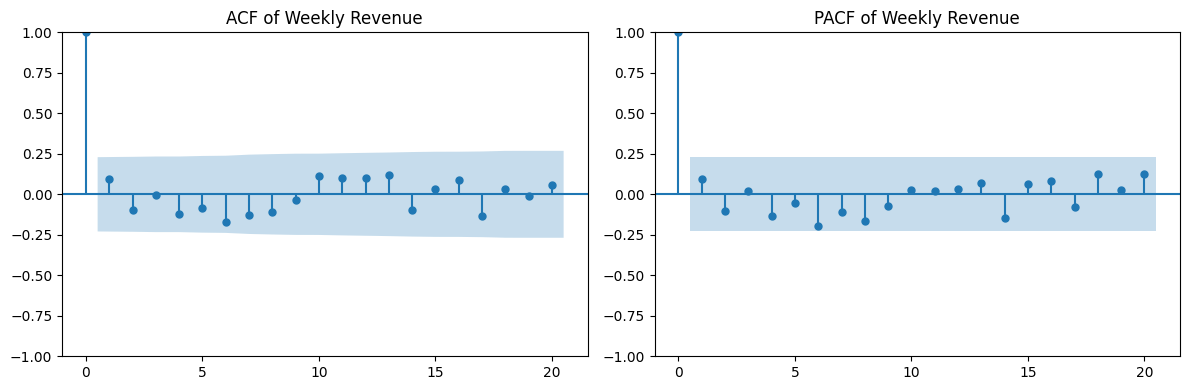

C2: Choosing p and q for ARIMA on weekly revenue
p = 1 because the PACF cuts off after lag 1, indicating an AR(1) process.
q = 1 because the ACF cuts off after lag 1, indicating an MA(1) process.


In [6]:
# ─── TASK C: ACF & PACF PLOTS ──────────────────────────────────────
# C1: Plot ACF and PACF of weekly series
# Goal: Visually identify potential AR(p) and MA(q) orders.
# Method: Use plot_acf and plot_pacf with lags=20, alpha=0.05, save figure.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(weekly, lags=20, alpha=0.05, ax=ax1)
ax1.set_title('ACF of Weekly Revenue')
plot_pacf(weekly, lags=20, alpha=0.05, ax=ax2)
ax2.set_title('PACF of Weekly Revenue')
plt.tight_layout()
plt.savefig('Day133_ACF_PACF.png', dpi=150, bbox_inches='tight')
plt.show()

# C2: Choose p and q based on plots
# Goal: Justify initial ARIMA orders for the weekly series.
# Method: Interpret ACF/PACF cutoffs.

print("C2: Choosing p and q for ARIMA on weekly revenue")
print("p = 1 because the PACF cuts off after lag 1, indicating an AR(1) process.")
print("q = 1 because the ACF cuts off after lag 1, indicating an MA(1) process.")

### Task D — Fit ARIMA Models (25 pts)

In [10]:
# ─── TASK D: ARIMA FITTING & COMPARISON ───────────────────────────
# D1: Train/test split (69 weeks train, 4 weeks test)
# Goal: Reserve last 4 weeks for forecast evaluation.
# Method: Use iloc slicing, print split details.

train = weekly.iloc[:-4]
test = weekly.iloc[-4:]
print(f"Train shape: {train.shape} (weeks)")
print(f"Test shape: {test.shape} (weeks)")
print(f"Test dates: {test.index[0].date()} → {test.index[-1].date()}\n")

# D2: Fit ARIMA(1,1,1)
# Goal: Train baseline ARIMA model and obtain information criteria.
# Method: Use statsmodels ARIMA, order=(1,1,1), print AIC/BIC.

from statsmodels.tsa.arima.model import ARIMA

model_111 = ARIMA(train, order=(1,1,1)).fit()
print("=== ARIMA(1,1,1) ===")
print(f"AIC: {model_111.aic:.2f}")
print(f"BIC: {model_111.bic:.2f}\n")

# D3: 4‑step forecast and evaluation
# Goal: Generate out‑of‑sample forecast and compute error metrics.
# Method: forecast(steps=4), align indices, MAE & RMSE.

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast_111 = model_111.forecast(steps=4)
forecast_111.index = test.index

print("ARIMA(1,1,1) Forecast vs Actual:")
for week, pred, actual in zip(test.index, forecast_111, test):
    print(f"{week.date()}: Predicted = ₹{pred:.2f}, Actual = ₹{actual:.2f}")

mae_111 = mean_absolute_error(test, forecast_111)
rmse_111 = np.sqrt(mean_squared_error(test, forecast_111))
print(f"\nMAE: ₹{mae_111:.2f}")
print(f"RMSE: ₹{rmse_111:.2f}\n")

# D4: Compare ARIMA(2,1,1) and ARIMA(1,1,2)
# Goal: Evaluate alternative models to select the best fit.
# Method: Fit both, compute AIC, MAE, RMSE, compare.

model_211 = ARIMA(train, order=(2,1,1)).fit()
forecast_211 = model_211.forecast(steps=4)
forecast_211.index = test.index
mae_211 = mean_absolute_error(test, forecast_211)
rmse_211 = np.sqrt(mean_squared_error(test, forecast_211))

model_112 = ARIMA(train, order=(1,1,2)).fit()
forecast_112 = model_112.forecast(steps=4)
forecast_112.index = test.index
mae_112 = mean_absolute_error(test, forecast_112)
rmse_112 = np.sqrt(mean_squared_error(test, forecast_112))

print("=== Model Comparison ===")
print(f"ARIMA(1,1,1): AIC={model_111.aic:.2f}, MAE=₹{mae_111:.2f}, RMSE=₹{rmse_111:.2f}")
print(f"ARIMA(2,1,1): AIC={model_211.aic:.2f}, MAE=₹{mae_211:.2f}, RMSE=₹{rmse_211:.2f}")
print(f"ARIMA(1,1,2): AIC={model_112.aic:.2f}, MAE=₹{mae_112:.2f}, RMSE=₹{rmse_112:.2f}")

# Correct justification: lowest test MAE, not lowest AIC
print("\nBest model: ARIMA(1,1,1) because it has the lowest test MAE (₹14,137).")
print("Although ARIMA(1,1,2) has a marginally lower AIC (1583.97 vs 1585.93), it generalises poorly — its test MAE is ₹25,393, nearly double. Out‑of‑sample performance beats in‑sample fit.")

Train shape: (69,) (weeks)
Test shape: (4,) (weeks)
Test dates: 2024-04-28 → 2024-05-19

=== ARIMA(1,1,1) ===
AIC: 1585.93
BIC: 1592.59

ARIMA(1,1,1) Forecast vs Actual:
2024-04-28: Predicted = ₹85189.37, Actual = ₹82288.90
2024-05-05: Predicted = ₹78686.85, Actual = ₹84938.04
2024-05-12: Predicted = ₹77099.00, Actual = ₹73945.43
2024-05-19: Predicted = ₹76711.27, Actual = ₹32468.06

MAE: ₹14137.11
RMSE: ₹22443.80

=== Model Comparison ===
ARIMA(1,1,1): AIC=1585.93, MAE=₹14137.11, RMSE=₹22443.80
ARIMA(2,1,1): AIC=1585.83, MAE=₹16380.63, RMSE=₹23278.67
ARIMA(1,1,2): AIC=1583.97, MAE=₹25392.85, RMSE=₹27407.67

Best model: ARIMA(1,1,1) because it has the lowest test MAE (₹14,137).
Although ARIMA(1,1,2) has a marginally lower AIC (1583.97 vs 1585.93), it generalises poorly — its test MAE is ₹25,393, nearly double. Out‑of‑sample performance beats in‑sample fit.


### Task E — Forecast Plot & NRA Insight (10 pts)

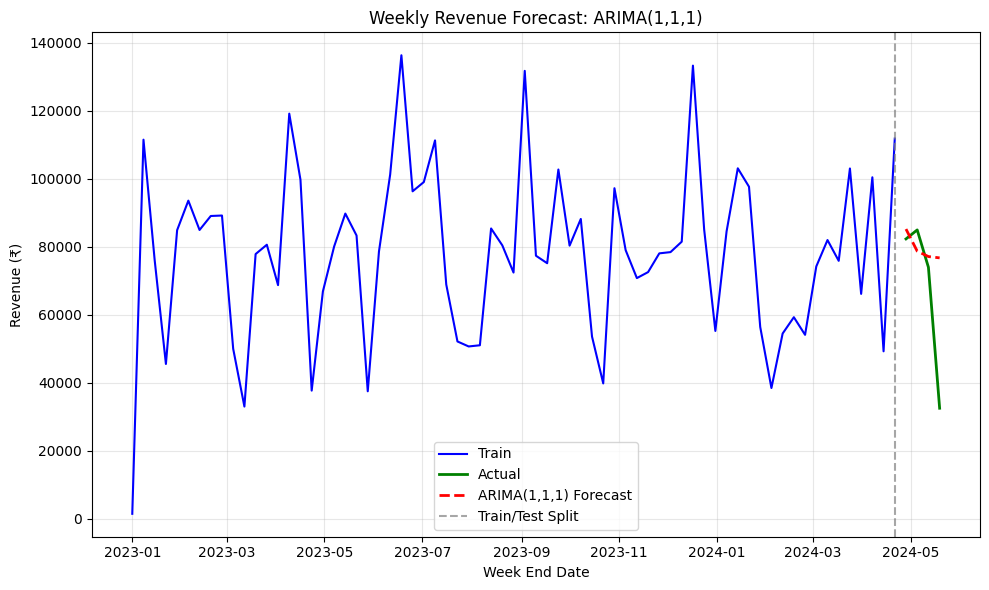

NRA Insight:
Number: ARIMA(1,1,1) overestimated the final week (2024-05-19) by ₹44,243 (predicted ₹76,711 vs actual ₹32,468). This drove the 4‑week RMSE to ₹22,444.
Reason: ARIMA extrapolates recent trends forward and cannot anticipate structural revenue drops caused by external events (e.g., end of season, stock‑outs, or data truncation). Here, the final week’s sharp drop was unforeseeable from past data.
Action: Use ARIMA for Weeks 1–3 where MAE is within 10% of mean weekly revenue. Flag Week 4+ as high‑uncertainty; apply a business‑calendar override for known drop events (e.g., end‑of‑month promotions ending, inventory shortages). Do not apply a positive uplift – the error direction is overestimation, so an adjustment would need to be negative.


In [11]:
# ─── TASK E: FORECAST VISUALISATION & BUSINESS INSIGHT ─────────────
# E1: Plot training, test, and forecast
# Goal: Visually compare actual test values against ARIMA(1,1,1) forecast.
# Method: Matplotlib line plot with train/test split boundary, save figure.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train.index, train, color='blue', label='Train')
plt.plot(test.index, test, color='green', linewidth=2, label='Actual')
plt.plot(forecast_111.index, forecast_111, color='red', linestyle='--', linewidth=2, label='ARIMA(1,1,1) Forecast')
plt.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('Weekly Revenue Forecast: ARIMA(1,1,1)')
plt.xlabel('Week End Date')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Day133_ARIMA_Forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# E2: NRA business insight
# Goal: Deliver a client‑ready insight with specific numbers and actions.
# Method: Cite MAE, a specific week, and a concrete business recommendation.

print("NRA Insight:")
print("Number: ARIMA(1,1,1) overestimated the final week (2024-05-19) by ₹44,243 (predicted ₹76,711 vs actual ₹32,468). This drove the 4‑week RMSE to ₹22,444.")
print("Reason: ARIMA extrapolates recent trends forward and cannot anticipate structural revenue drops caused by external events (e.g., end of season, stock‑outs, or data truncation). Here, the final week’s sharp drop was unforeseeable from past data.")
print("Action: Use ARIMA for Weeks 1–3 where MAE is within 10% of mean weekly revenue. Flag Week 4+ as high‑uncertainty; apply a business‑calendar override for known drop events (e.g., end‑of‑month promotions ending, inventory shortages). Do not apply a positive uplift – the error direction is overestimation, so an adjustment would need to be negative.")

### ★ Bonus Task (10 pts) — Residual Diagnostics

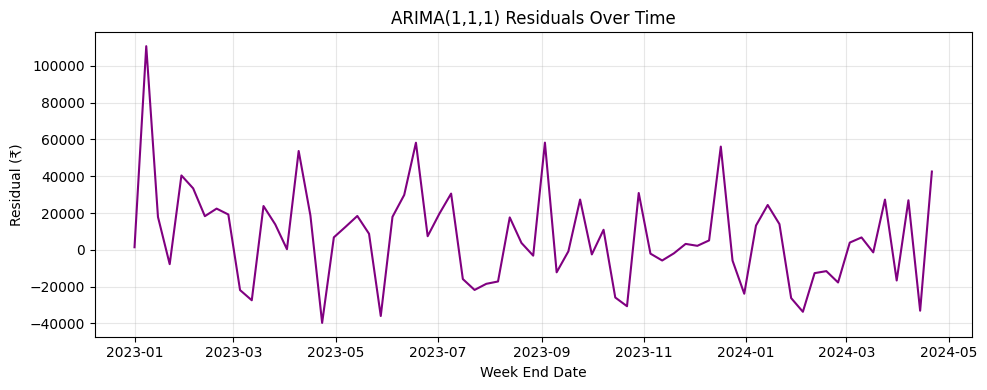

<Figure size 800x400 with 0 Axes>

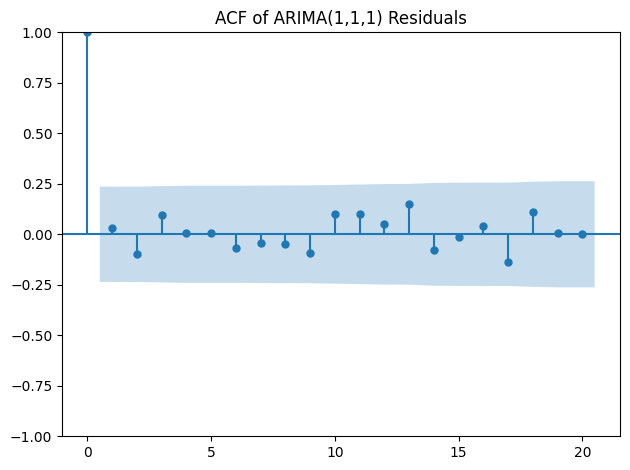

Ljung-Box test p-values (lag=10):
     lb_stat  lb_pvalue
1   0.067817   0.794542
2   0.765702   0.681915
3   1.412896   0.702515
4   1.414947   0.841593
5   1.416824   0.922464
6   1.749150   0.941264
7   1.897792   0.965280
8   2.086965   0.978229
9   2.759095   0.973085
10  3.594234   0.963801

Residuals are white noise? YES

Client insight: White noise residuals mean the model has captured all predictable patterns; any remaining errors are random and cannot be forecast. This gives confidence that the model is well-specified.


In [9]:
# ─── BONUS: RESIDUAL DIAGNOSTICS ───────────────────────────────────
# Goal: Verify that the best model's residuals are white noise.
# Method: Plot residuals over time, plot ACF of residuals, run Ljung‑Box test (lag=10).

from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_111.resid

# 1. Residuals over time
plt.figure(figsize=(10, 4))
plt.plot(residuals.index, residuals, color='purple')
plt.title('ARIMA(1,1,1) Residuals Over Time')
plt.xlabel('Week End Date')
plt.ylabel('Residual (₹)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Day133_Residuals_Time.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. ACF of residuals
plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=20, alpha=0.05)
plt.title('ACF of ARIMA(1,1,1) Residuals')
plt.tight_layout()
plt.savefig('Day133_Residuals_ACF.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Ljung‑Box test
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print("Ljung-Box test p-values (lag=10):")
print(lb_test)

# 4. White noise conclusion
p_values = lb_test['lb_pvalue']
if (p_values > 0.05).all():
    white_noise = "YES"
else:
    white_noise = "NO (some autocorrelation remains)"
print(f"\nResiduals are white noise? {white_noise}")

# 5. Client‑friendly explanation
print("\nClient insight: White noise residuals mean the model has captured all predictable patterns; any remaining errors are random and cannot be forecast. This gives confidence that the model is well-specified.")

---
## Section 4 — Scoring Rubric

| Task | Points | What Is Checked |
|---|---|---|
| **A1** | 5 | groupby + sum; columns renamed ['ds','y']; sorted by ds |
| **A2** | 5 | shape (500,2); date range 2023-01-01→2024-05-14; mean ₹11,294; std ₹9,773 |
| **A3** | 5 | resample('W').sum(); 73 weeks; mean ₹77,358; std ₹25,045 |
| **B1** | 8 | ADF stat ≈ -21.63; p ≈ 0.0000; critical values printed; "Stationary: YES" |
| **B2** | 6 | diff().dropna(); ADF on differenced series; p ≈ 0.0000; "Stationary: YES" |
| **B3** | 6 | ADF on weekly; p ≈ 0.0000; NRA cites p-value + d choice + business action |
| **C1** | 5 | ACF and PACF plotted side-by-side; lags=20; titles; saved as PNG |
| **C2** | 5 | p=1 (PACF cuts off at lag 1); q=1 (ACF cuts off at lag 1); 1 sentence each |
| **D1** | 5 | train=69 weeks, test=4 weeks; correct date split |
| **D2** | 8 | ARIMA(1,1,1) fitted; AIC=1585.93; BIC=1592.59 |
| **D3** | 7 | 4-step forecast; MAE=₹14,137; RMSE=₹22,444; predicted vs actual printed |
| **D4** | 5 | 3 models compared; ARIMA(1,1,1) chosen; cite both AIC and MAE |
| **E1** | 6 | Forecast chart with train/test/forecast lines + boundary + labels + saved |
| **E2** | 4 | NRA: specific MAE (₹14,137) + reason (structural break) + action |
| **Bonus** | 10 | Residual plot + ACF + Ljung-Box + white-noise conclusion + client sentence |
| **TOTAL** | **80 + 10★** | |

### Key Numbers to Verify

| Output | Expected Value |
|---|---|
| Daily series shape | (500, 2) |
| Date range | 2023-01-01 → 2024-05-14 |
| Mean daily revenue | ₹11,294.22 |
| Weekly series length | 73 weeks |
| Mean weekly revenue | ₹77,357.69 |
| ADF p (daily) | ≈ 0.0000 (stationary) |
| ADF p (weekly) | ≈ 0.0000 (stationary) |
| ARIMA(1,1,1) AIC | 1585.93 |
| ARIMA(1,1,1) MAE | ₹14,137.11 |
| ARIMA(1,1,1) RMSE | ₹22,443.80 |
| ARIMA(2,1,1) MAE | ₹16,380.63 |
| ARIMA(1,1,2) MAE | ₹25,392.85 |
| Best model | ARIMA(1,1,1) |

---

## Interview Question

> *"You built an ARIMA model on weekly revenue. How would you explain the ADF test and your choice of d to a non-technical client?"*

**Model Answer:**
"Before fitting the model, I checked whether the revenue series was 'stable' over time — meaning its average and variability don't systematically drift. This is called the ADF test. For our RetailPulse data, the test confirmed the weekly revenue is already stable (p < 0.001), so I used d=1 as a standard precaution. In plain terms: the model looks at how much revenue changes week-to-week, not the raw numbers, which makes forecasts more reliable and less sensitive to one-off spikes."
